In [1]:
"""
INTEGRATED FIGURE 1: Complete Analysis Pipeline
Fixed version with proper execution order
"""

# %%
# =============================================================================
# IMPORTS AND CONFIGURATION
# =============================================================================
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import warnings
from scipy.sparse import csr_matrix
from scipy import stats
from datetime import datetime
from tqdm import tqdm
from scipy import stats
from scipy.sparse import issparse
import sys 

warnings.filterwarnings("ignore")

# Import ATSE coordination functions
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation') 

# Plotting configuration
sns.set_theme(context="notebook", style="white")
plt.rcParams.update({
    'font.size': 13,
    'axes.titlesize': 13,
    'axes.labelsize': 13,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 12,
    'figure.titlesize': 12,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1.0,
    'axes.grid': False,
})

# Import utility functions - simple direct import
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from utils import *
from figure_plotting import *

# Import all functions from /gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/atse_viz.py
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-analysis/Multi_Species_Splicing_Foundation/shared_utils/')
from atse_viz import *
import gffutils

gtf_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/all_samples_sp_collapse_all_chr_no_treatment_hashid_isoform_full.gtf"
db_file = "/gpfs/commons/groups/knowles_lab/Megan/encode_pacbio/paper_figures/isoform_gazers/long_read_hg38.db"

# Load the database
db_human = gffutils.FeatureDB(db_file, keep_order=True)

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Visualization imports successful!


In [2]:
# Setup
today = datetime.now().strftime("%Y%m%d")
BASE_DIR = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION"

# =========================================================================
# PART 1: Load and Preprocess Data
# =========================================================================

print("\n" + "="*60)
print("PART 1: DATA LOADING AND PREPROCESSING")
print("="*60)

ATSE_FILE_PATH = f"{BASE_DIR}/ATSE_mapper/ATSE_files/HUMAN_FOUNDATION_ATSE_FILE_unanno_also_2025-09-21_05-02-35.txt.gz"
full_atse_map = pd.read_csv(ATSE_FILE_PATH, sep="\t")

print("Loading data...")

output_dir="/gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/ATSE_plotter/pdfs"
# make output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)


PART 1: DATA LOADING AND PREPROCESSING
Loading data...


In [ ]:
chr14_69767251_69768137_+	

Unique transcripts: {'s10a5a6ba2e2ca481:e58233707df414de4', 'ENST00000557154.6', 's636ffbede60924af:e15c3ef1d9c0b329d', 's76150d455accbd16:eef847050e8b38df9', 's06ec675a26a020ae:e0763ed6e11813770', 'sb0b8239cb848c3fb:eeb54285b71ddb488', 's5849f0c8e0d40d6f:e58b76331a575ed04', 's953d00e817d261ad:e0763ed6e11813770', 's98ba268261218f86:e2ffdd2d9eb49a28e', 'sb04047ff057412f1:eeb54285b71ddb488', 's4f60601ade9021d9:ec546aebf89033325', 'sb0b8239cb848c3fb:ece48d8f9514cd7c7', 's0edd3a375731029e:eef847050e8b38df9', 'sa6b6429cde1af765:eeb54285b71ddb488', 's99b9a7cdddd183b9:ed15b6f76e490fd89', 's31481b270fe9fd9b:ed1150da6c945d2a8', 'sb0b8239cb848c3fb:e84202a59b7196fda', 's31481b270fe9fd9b:eac3b15261d4c7c29', 'sb0b8239cb848c3fb:ea365847984e63f6c', 's8cc4321167771f13:e58233707df414de4', 's76150d455accbd16:e689e52b8f934b4fe', 's99b9a7cdddd183b9:eafc55b651a6d9e26', 's953d00e817d261ad:e7057790fda023aa0', 's30c620e5eeaa0fb3:eb4fe886ba5679380', 's06ec675a26a020ae:e12dbc964afa0bfa7', 's636ffbede60924af:ef0

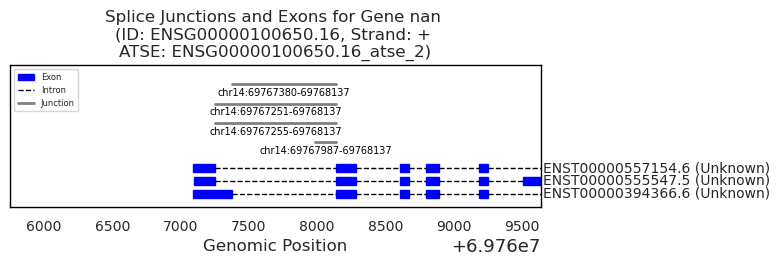

ATSE visualization saved: /gpfs/commons/home/kisaev/Leaflet-analysis/Human_Splicing_Foundation/ATSE_plotter/pdfs/213659_human_nan_ENSG00000100650.16_atse_2.pdf


{'junctions':                         event_id             gene_id  gene_name  gene_types  \
 11031  ENSG00000100650.16_atse_2  ENSG00000100650.16        NaN         NaN   
 11032  ENSG00000100650.16_atse_2  ENSG00000100650.16        NaN         NaN   
 11033  ENSG00000100650.16_atse_2  ENSG00000100650.16        NaN         NaN   
 11034  ENSG00000100650.16_atse_2  ENSG00000100650.16        NaN         NaN   
 
        num_junctions           event_type chromosome strand  atse_start  \
 11031              4  alternative_5_prime      chr14      +    69767251   
 11032              4  alternative_5_prime      chr14      +    69767251   
 11033              4  alternative_5_prime      chr14      +    69767251   
 11034              4  alternative_5_prime      chr14      +    69767251   
 
        atse_end  ...  acceptor_usage  donor_total_reads  acceptor_total_reads  \
 11031  69768137  ...          1.0000            2993652                 39973   
 11032  69768137  ...          0.6100  

In [10]:
human_event = "ENSG00000100650.16_atse_2" #"ENSG00000166974.13_atse_2" #"ENSG00000137033.12_atse_1"
visualize_atse_event(human_event, full_atse_map, db_human,
                 species="human", base_width=8, 
                       trans_height=0.55, output_dir=output_dir,
                  padding=500, show_junc_lines=False, filter_ensembl_transcripts=True)